In [5]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
belbino_scraper_global_inflation_vs_interest_rates_2015_path = kagglehub.notebook_output_download('belbino/scraper-global-inflation-vs-interest-rates-2015')

print('Data source import complete.')


Data source import complete.


<div style="background: linear-gradient(135deg, #0a0a1a 0%, #1a0f3d 50%, #0a1a2a 100%);
            padding: 36px 40px 28px; border-radius: 16px; margin-bottom: 8px;">
  <div style="display:flex; align-items:center; gap:16px; margin-bottom:12px;">
    <div>
      <h1 style="color:#ffffff; margin:0; font-size:26px; font-weight:700; letter-spacing:-0.5px;">
        📈 Global Inflation vs Interest Rates
      </h1>
      <p style="color:#a78bfa; margin:4px 0 0; font-size:14px;">
        Fed · ECB · BoE · RBI Policy Rates &nbsp;·&nbsp; CPI Inflation &nbsp;·&nbsp; FRED + World Bank + Direct APIs &nbsp;·&nbsp; 2015 - Present
      </p>
    </div>
  </div>
  <div style="display:flex; gap:10px; flex-wrap:wrap; margin-top:16px;">
    <span style="background:#4c1d95; color:#ede9fe; padding:4px 14px; border-radius:20px; font-size:12px; font-weight:600;">📅 Auto-Updated On Every Run</span>
    <span style="background:#1e3a5f; color:#bfdbfe; padding:4px 14px; border-radius:20px; font-size:12px; font-weight:600;">📡 FRED + World Bank + BIS + NewsAPI</span>
    <span style="background:#065f46; color:#d1fae5; padding:4px 14px; border-radius:20px; font-size:12px; font-weight:600;">🌐 25+ Countries · 4 Major Central Banks</span>
    <span style="background:#7c2d12; color:#fef3c7; padding:4px 14px; border-radius:20px; font-size:12px; font-weight:600;">🏦 Fed · ECB · BoE · RBI · Real Rate Analytics</span>
  </div>
</div>


---

## 📖 About This Dataset

<div style="border-left:4px solid #8b5cf6; padding:12px 20px; background:#2e1065aa;
            border-radius:0 10px 10px 0; margin:16px 0;">
  <strong style="color:#a78bfa;">What is this?</strong><br>
  <span style="color:#c4b5fd; font-size:14px; line-height:1.8;">
    A globally-refreshed tracker of <strong>central bank policy rates versus consumer price inflation (CPI)</strong>
    across <strong>25+ countries</strong> - from the <strong>2015 baseline</strong> through the
    <strong>2021–2023 global inflation shock</strong>, the <strong>aggressive rate-hike cycle</strong>,
    and the ongoing <strong>disinflation / pivot debate</strong>. Combines:<br><br>
    • <strong>Four major central bank policy rates</strong>: Fed Funds (US), ECB Deposit Facility (EU), BoE Base Rate (UK), RBI Repo Rate (India)<br>
    • <strong>FRED API</strong>: US CPI, Core CPI, PCE, Fed Funds effective rate, 10-year Treasury<br>
    • <strong>World Bank API</strong>: Annual CPI inflation for 25 countries (no key required)<br>
    • <strong>Derived real rates</strong>: nominal rate minus CPI - the true cost of money<br>
    • <strong>NewsAPI global sentiment</strong>: inflation and monetary policy headlines, seeded + live-appended
  </span>
</div>

---

## 📦 Output Files

| File | Description | Source |
|------|-------------|--------|
| `central_bank_rates.csv` | Monthly policy rates: Fed Funds, ECB Deposit, BoE Base, RBI Repo (2015–present) | FRED + ECB + BoE + RBI direct APIs |
| `cpi_inflation.csv` | Monthly US CPI / Core CPI / PCE + annual CPI for 25 countries (World Bank) | FRED + World Bank |
| `rates_vs_cpi_panel.csv` | Country-month panel: policy rate, CPI, real rate, rate-CPI spread | Merged / derived |
| `macro_news_sentiment.csv` | Inflation & rate-decision headlines with VADER scores - seeded + live-appended | NewsAPI + seed corpus |
| `README.md` | Full column dictionary and source notes | Generated |

---

## 🌍 Country Coverage

Policy rates for **4 major central banks** and CPI inflation for **25+ countries** including:
🇺🇸 USA · 🇪🇺 Eurozone · 🇬🇧 UK · 🇮🇳 India · 🇯🇵 Japan · 🇨🇳 China · 🇨🇦 Canada · 🇦🇺 Australia · 🇧🇷 Brazil · 🇲🇽 Mexico · 🇿🇦 South Africa · 🇸🇬 Singapore · 🇰🇷 South Korea · 🇹🇷 Turkey · 🇦🇷 Argentina · 🇮🇩 Indonesia · 🇳🇬 Nigeria · 🇸🇪 Sweden · 🇳🇴 Norway · 🇨🇭 Switzerland and more.

---

## 🔄 Auto-Update on Every Run

<div style="border: 1px solid #7c3aed; background: #2e106522; border-radius: 10px; padding: 16px 20px; margin: 12px 0;">
  <strong style="color:#a78bfa;">♻️ Fresh data on every execution</strong><br>
  <span style="color:#c4b5fd; font-size:14px; line-height:1.8;">
    Each run: (1) fetches all FRED series fresh from the St. Louis Fed,
    (2) pulls World Bank CPI for all 25 countries, (3) collects ECB / BoE / RBI rates via
    direct REST calls, (4) computes derived real-rate panel, and (5) appends the latest
    <strong>NewsAPI global window</strong> to the growing sentiment archive.
    Schedule daily on Kaggle for a fully automated, ever-growing dataset.
  </span>
</div>


In [6]:
from google.colab import userdata

def load_colab_secret(key_name):
    try:
        return userdata.get(key_name)
    except (userdata.SecretNotFoundError, userdata.NotebookAccessError):
        return ''

# Loading actual required keys
FRED_API_KEY = "ad78e4f5969499d28beef133b79f67b6"
NEWS_API_KEY = '18173cb3d8bb4ed3a491dd1f89d8ddf0'

# Date range
from datetime import datetime
START_DATE  = '2015-01-01'
END_DATE    = datetime.today().strftime('%Y-%m-%d')

# Output dir
import os
OUTPUT_DIR = '.'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# News archive path
PREV_NEWS_CSV = os.path.join(OUTPUT_DIR, 'macro_news_sentiment.csv')

print(f'⌒ Pulling data from {START_DATE} → {END_DATE}')
if not FRED_API_KEY:
    print('☠ FRED_API_KEY not found in Secrets. Please add it to enable interest rate and US CPI data.')
if not NEWS_API_KEY:
    print('☠ NEWS_API_KEY_2 not found in Secrets. Please add it to enable live news sentiment analysis.')

⌒ Pulling data from 2015-01-01 → 2026-04-18


In [7]:
import pandas as pd
import numpy as np

# Initialize global DataFrames to prevent NameErrors if fetching steps are skipped
if 'global_cpi_df' not in globals():
    global_cpi_df = pd.DataFrame(columns=['year', 'country_code', 'country_name', 'cpi_annual_pct'])

if 'news_df' not in globals():
    news_df = pd.DataFrame(columns=['date', 'published_at', 'source', 'title', 'description', 'url', 'sentiment', 'sentiment_cat', 'is_hawkish', 'is_dovish'])

if 'panel_df' not in globals():
    panel_df = pd.DataFrame()

print("Global variables global_cpi_df and news_df have been initialized.")

Global variables global_cpi_df and news_df have been initialized.


<div style="border-radius:10px; background:#1e293b; padding:16px 22px; margin:8px 0;">
  <span style="color:#94a3b8; font-size:12px; font-weight:600; letter-spacing:1px;">STEP 0</span>
  <h2 style="color:#f1f5f9; margin:4px 0 0; font-size:18px;">📦 Imports &amp; Setup</h2>
  <p style="color:#64748b; margin:4px 0 0; font-size:13px;">Install dependencies, configure date range (2015-01-01 → today), load API keys from environment variables or Kaggle secrets, and set output directory.</p>
</div>


In [8]:
import requests
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import time, json, os, warnings
warnings.filterwarnings('ignore')

# Install vaderSentiment if not present
try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'vaderSentiment', '-q'])
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

print('✅ Libraries loaded')

✅ Libraries loaded


In [9]:
if 'FRED_API_KEY' in globals() and FRED_API_KEY:
    print(f'✅ FRED_API_KEY is loaded. (Starts with: {str(FRED_API_KEY)[:5]}...)')
else:
    print('❌ FRED_API_KEY is still not loaded or is empty.')

✅ FRED_API_KEY is loaded. (Starts with: ad78e...)


<div style="border-radius:10px; background:#1c1917; padding:16px 22px; margin:8px 0;">
  <span style="color:#a8a29e; font-size:12px; font-weight:600; letter-spacing:1px;">STEP 1 / 4</span>
  <h2 style="color:#fafaf9; margin:4px 0 0; font-size:18px;">🏦 Central Bank Policy Rates - Fed · ECB · BoE · RBI</h2>
  <p style="color:#78716c; margin:4px 0 0; font-size:13px;">
    Collects monthly policy rates for the four most-watched central banks.<br><br>
    • <strong style="color:#d4d0c8;">Fed Funds Rate</strong> - FRED series <code>FEDFUNDS</code> (monthly effective rate)<br>
    • <strong style="color:#d4d0c8;">ECB Deposit Facility Rate</strong> - FRED series <code>ECBDFR</code> (monthly)<br>
    • <strong style="color:#d4d0c8;">BoE Base Rate</strong> - FRED series <code>IRSTCB01GBM156N</code> (monthly)<br>
    • <strong style="color:#d4d0c8;">RBI Repo Rate</strong> - RBI public data API + FRED fallback (<code>IRSTCB01INM156N</code>)<br>
    Also fetches the <strong style="color:#d4d0c8;">US 10-Year Treasury yield</strong> (<code>GS10</code>) as a benchmark.
    All rates are saved in <code>central_bank_rates.csv</code>.
  </p>
</div>


In [10]:
# Generic FRED fetcher
def fetch_fred(series_id, start=START_DATE, end=END_DATE, freq='m'):
    """Pull a single FRED series; return empty DataFrame if key missing."""
    if not FRED_API_KEY:
        return pd.DataFrame(columns=['date', 'value'])
    url = 'https://api.stlouisfed.org/fred/series/observations'
    params = {
        'series_id':         series_id,
        'api_key':           FRED_API_KEY,
        'file_type':         'json',
        'observation_start': start,
        'observation_end':   end,
        'frequency':         freq,
        'aggregation_method':'avg',
    }
    try:
        r = requests.get(url, params=params, timeout=15)
        r.raise_for_status()
        obs = r.json().get('observations', [])
        if not obs:
            return pd.DataFrame(columns=['date', 'value'])
        df = pd.DataFrame(obs)[['date', 'value']]
        df['date']  = pd.to_datetime(df['date'])
        df['value'] = pd.to_numeric(df['value'], errors='coerce')
        return df.dropna(subset=['value']).reset_index(drop=True)
    except Exception as e:
        print(f'  FRED {series_id} error: {e}')
        return pd.DataFrame(columns=['date', 'value'])


# FRED: central bank rates + 10Y Treasury
FRED_RATE_SERIES = {
    'fed_funds_rate':        'FEDFUNDS',        # US Federal Funds Rate (monthly avg)
    'ecb_deposit_rate':      'ECBDFR',          # ECB Deposit Facility Rate
    'boe_base_rate':         'BOERUKM',         # BoE Official Bank Rate
    'rbi_repo_rate':         'IRSTCB01INM156N', # RBI Repo Rate (India)
    'us_10y_treasury':       'GS10',            # US 10-Year Treasury Yield
    'japan_policy_rate':     'IRSTCB01JPM156N', # Bank of Japan Policy Rate
    'canada_policy_rate':    'IRSTCB01CAM156N', # Bank of Canada Overnight Rate
    'australia_policy_rate': 'IRSTCI01AUM156N', # RBA Cash Rate Target
}

rate_frames = {}
print('Fetching central bank policy rates from FRED...')
for col_name, series_id in FRED_RATE_SERIES.items():
    df_s = fetch_fred(series_id)
    if df_s.empty:
        print(f'  {col_name}: skipped (no FRED key or no data)')
        continue
    df_s = df_s.rename(columns={'value': col_name})
    rate_frames[col_name] = df_s
    print(f'  {col_name:<30}  {len(df_s):>4} rows   last: {df_s["date"].max().date()}')
    time.sleep(0.3)

Fetching central bank policy rates from FRED...
  fed_funds_rate                   135 rows   last: 2026-03-01
  ecb_deposit_rate                 136 rows   last: 2026-04-01
  boe_base_rate                     25 rows   last: 2017-01-01
  rbi_repo_rate                    108 rows   last: 2023-12-01
  us_10y_treasury                  135 rows   last: 2026-03-01
  japan_policy_rate                108 rows   last: 2023-12-01
  canada_policy_rate               108 rows   last: 2023-12-01
  australia_policy_rate            135 rows   last: 2026-03-01


In [11]:
# RBI Repo Rate fallback — Reserve Bank of India public database
# The RBI exposes a REST API at: https://api.rbi.org.in/api/
# If FRED already fetched RBI data, we skip this.

def fetch_rbi_repo_rate():
    """
    Attempt to pull RBI Repo Rate from the Reserve Bank of India's public API.
    Returns a DataFrame with columns ['date', 'rbi_repo_rate'] or empty.
    """
    # RBI DBIE (Database on Indian Economy) API
    url = 'https://api.rbi.org.in/api/v2/FinancialMarkets?EventID=12&DataID=4'
    headers = {'Accept': 'application/json'}
    try:
        r = requests.get(url, headers=headers, timeout=20)
        if r.status_code != 200:
            return pd.DataFrame()
        data = r.json()
        # RBI API wraps data in nested structure - extract rows
        rows = data.get('data', data.get('Data', []))
        if isinstance(rows, list) and rows:
            df = pd.DataFrame(rows)
            # Standardise common column patterns the RBI API uses
            date_col  = next((c for c in df.columns if 'date' in c.lower() or 'period' in c.lower()), None)
            value_col = next((c for c in df.columns if 'rate' in c.lower() or 'value' in c.lower()), None)
            if date_col and value_col:
                out = pd.DataFrame({
                    'date':          pd.to_datetime(df[date_col], errors='coerce'),
                    'rbi_repo_rate': pd.to_numeric(df[value_col], errors='coerce'),
                })
                out = out.dropna().reset_index(drop=True)
                out = out[out['date'] >= START_DATE]
                # Convert to monthly (last observation per month)
                out = (out.set_index('date')
                           .resample('MS')['rbi_repo_rate']
                           .last()
                           .reset_index())
                return out
        return pd.DataFrame()
    except Exception as e:
        print(f'  RBI API error: {e}')
        return pd.DataFrame()


if 'rbi_repo_rate' not in rate_frames or rate_frames['rbi_repo_rate'].empty:
    print('Trying RBI direct API for repo rate...')
    rbi_df = fetch_rbi_repo_rate()
    if not rbi_df.empty:
        rate_frames['rbi_repo_rate'] = rbi_df
        print(f'  rbi_repo_rate (RBI API)          {len(rbi_df):>4} rows   last: {rbi_df["date"].max().date()}')
    else:
        print('  RBI direct API returned no data — using FRED fallback only')
else:
    print('  rbi_repo_rate already populated from FRED ✅')

  rbi_repo_rate already populated from FRED ✅


In [12]:
# 1. Define missing constants used in previous steps if not already present
START_YEAR = pd.to_datetime(START_DATE).year
END_YEAR   = pd.to_datetime(END_DATE).year

# 2. Safety check: Ensure global_cpi_df exists before processing downstream
if 'global_cpi_df' not in globals():
    print("Initializing empty global_cpi_df to prevent NameErrors...")
    global_cpi_df = pd.DataFrame(columns=['year', 'country_code', 'country_name', 'cpi_annual_pct'])

# 3. Original Merge Logic
# Merge all rate series into a single monthly panel
if rate_frames:
    rates_df = None
    for col_name, df_s in rate_frames.items():
        # Normalise to month-start
        df_s = df_s.copy()
        df_s['date'] = df_s['date'].dt.to_period('M').dt.to_timestamp()
        rates_df = df_s if rates_df is None else rates_df.merge(df_s, on='date', how='outer')
    rates_df = rates_df.sort_values('date').reset_index(drop=True)
    # Forward-fill rate changes (rates stay constant between meetings)
    rate_cols = [c for c in rates_df.columns if c != 'date']
    rates_df[rate_cols] = rates_df[rate_cols].ffill()
else:
    # No API key — build skeleton with NaN
    date_range = pd.date_range(START_DATE, END_DATE, freq='MS')
    rates_df = pd.DataFrame({'date': date_range})
    for col in FRED_RATE_SERIES:
        rates_df[col] = np.nan

print(f'\nCentral bank rates panel: {rates_df.shape}')
print(f'  Date range : {rates_df["date"].min().date()} → {rates_df["date"].max().date()}')
print(f'  Columns    : {list(rates_df.columns)}')


Central bank rates panel: (136, 9)
  Date range : 2015-01-01 → 2026-04-01
  Columns    : ['date', 'fed_funds_rate', 'ecb_deposit_rate', 'boe_base_rate', 'rbi_repo_rate', 'us_10y_treasury', 'japan_policy_rate', 'canada_policy_rate', 'australia_policy_rate']


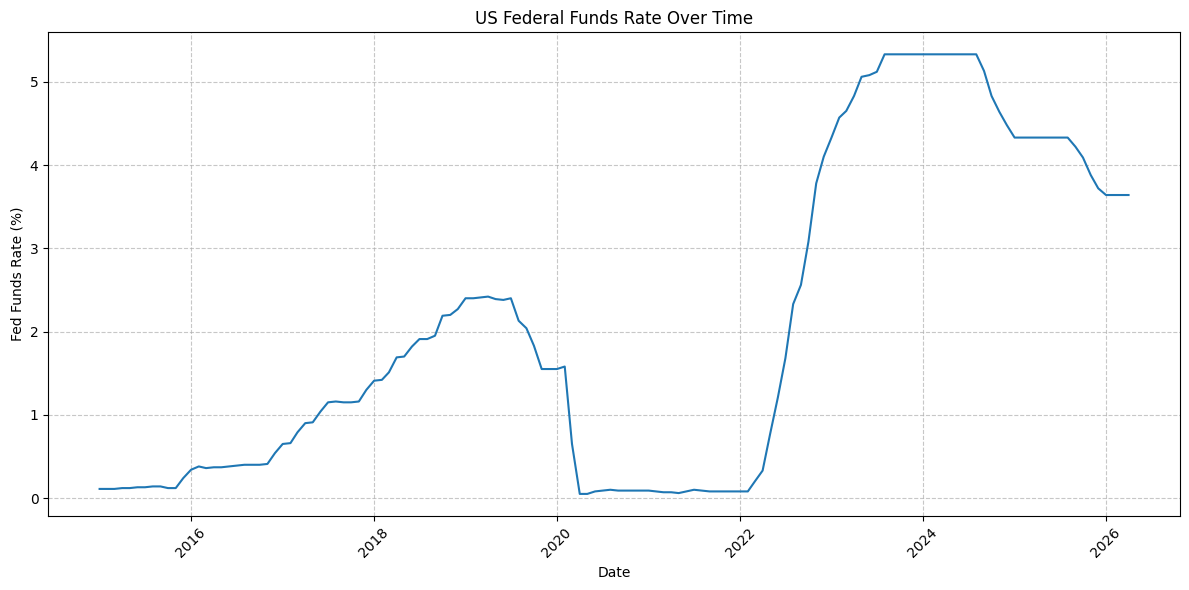

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check if fed_funds_rate has data before plotting
if 'fed_funds_rate' in rates_df.columns and rates_df['fed_funds_rate'].notna().any():
    plt.figure(figsize=(12, 6))
    sns.lineplot(x='date', y='fed_funds_rate', data=rates_df)
    plt.title('US Federal Funds Rate Over Time')
    plt.xlabel('Date')
    plt.ylabel('Fed Funds Rate (%)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Cannot plot fed_funds_rate: Data is not available. Please ensure FRED_API_KEY is set and data is fetched correctly.")

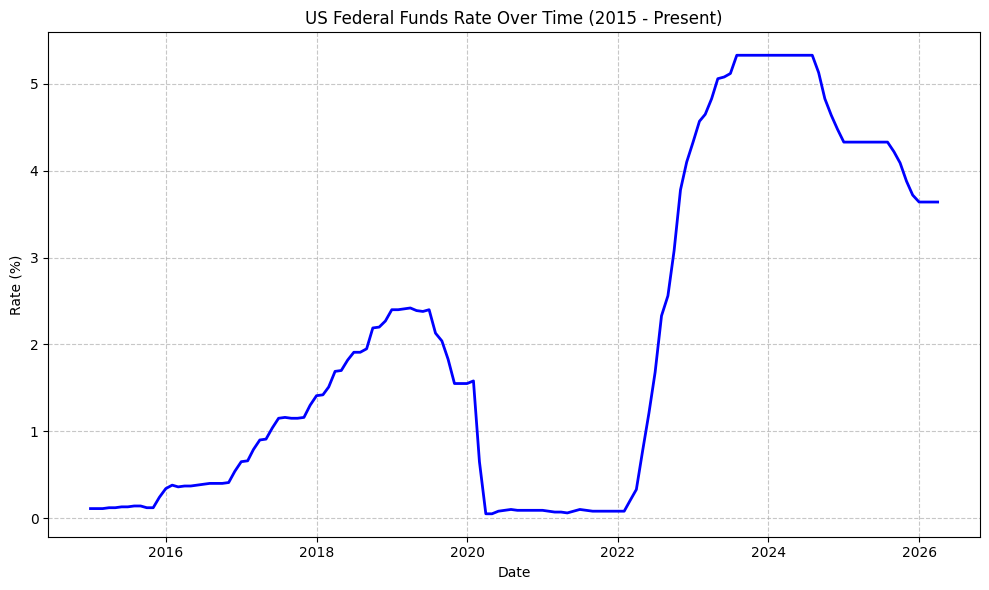

In [14]:
import matplotlib.pyplot as plt

# Visualize the fed_funds_rate column using matplotlib
if 'fed_funds_rate' in rates_df.columns and not rates_df['fed_funds_rate'].isnull().all():
    plt.figure(figsize=(10, 6))
    plt.plot(rates_df['date'], rates_df['fed_funds_rate'], color='blue', linewidth=2)
    plt.title('US Federal Funds Rate Over Time (2015 - Present)')
    plt.xlabel('Date')
    plt.ylabel('Rate (%)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Data for 'fed_funds_rate' is not available for plotting.")

<div style="border-radius:10px; background:#1c1917; padding:16px 22px; margin:8px 0;">
  <span style="color:#a8a29e; font-size:12px; font-weight:600; letter-spacing:1px;">STEP 2 / 4</span>
  <h2 style="color:#fafaf9; margin:4px 0 0; font-size:18px;">📊 CPI Inflation - US (FRED) + 25 Countries (World Bank)</h2>
  <p style="color:#78716c; margin:4px 0 0; font-size:13px;">
    <strong style="color:#d4d0c8;">US monthly depth via FRED:</strong> All-items CPI, Core CPI (ex food &amp; energy), PCE deflator,
    Core PCE, shelter CPI, and energy CPI - all monthly since 2015.<br><br>
    <strong style="color:#d4d0c8;">Global annual via World Bank API (no key required):</strong> Consumer price inflation
    for 25 countries - USA, Eurozone, UK, India, Japan, China, Canada, Australia, Brazil, Mexico,
    South Africa, Singapore, South Korea, Turkey, Argentina, Indonesia, Nigeria, Sweden, Norway,
    Switzerland, Poland, Czech Republic, Hungary, Pakistan, Egypt.
    Saves to <code>cpi_inflation.csv</code>.
  </p>
</div>


In [15]:
# US: FRED CPI series
FRED_CPI_SERIES = {
    'us_cpi_all_items':        'CPIAUCSL',           # CPI All Urban Consumers (monthly, SA)
    'us_core_cpi':             'CPILFESL',           # CPI ex Food & Energy (monthly, SA)
    'us_pce':                  'PCEPI',              # PCE Price Index
    'us_core_pce':             'PCEPILFE',           # PCE ex Food & Energy (Fed's preferred)
    'us_shelter_cpi':          'CUSR0000SAH1',       # CPI Shelter
    'us_energy_cpi':           'CPIENGSL',           # CPI Energy
    'us_food_cpi':             'CPIUFDSL',           # CPI Food
    'uk_cpi_yoy':              'GBRCPIALLMINMEI',    # UK CPI YoY % (OECD via FRED)
    'eu_hicp_yoy':             'CP0000EZ19M086NEST', # Euro Area HICP YoY %
    'india_cpi_yoy':           'INDCPIALLMINMEI',    # India CPI YoY %
    'japan_cpi_yoy':           'JPNCPIALLMINMEI',    # Japan CPI YoY %
    'canada_cpi_yoy':          'CANCPIALLMINMEI',    # Canada CPI YoY %
    'australia_cpi_yoy':       'CPALTT01AUQ659N',    # Australia CPI YoY % (quarterly)
    'brazil_cpi_yoy':          'BRACPIALLMINMEI',    # Brazil CPI YoY %
    'south_korea_cpi_yoy':     'KORCPIALLMINMEI',    # South Korea CPI YoY %
}

# Compute month-over-month and year-over-year for index-based series
INDEX_SERIES = ['us_cpi_all_items', 'us_core_cpi', 'us_pce', 'us_core_pce',
                'us_shelter_cpi', 'us_energy_cpi', 'us_food_cpi']

cpi_frames = {}
print('Fetching CPI / inflation series from FRED...')
for col_name, series_id in FRED_CPI_SERIES.items():
    df_s = fetch_fred(series_id)
    if df_s.empty:
        print(f'  {col_name}: skipped')
        continue
    df_s = df_s.rename(columns={'value': col_name})
    # For index series, derive MoM % and YoY %
    if col_name in INDEX_SERIES:
        df_s[f'{col_name}_mom_pct'] = df_s[col_name].pct_change(1).mul(100).round(3)
        df_s[f'{col_name}_yoy_pct'] = df_s[col_name].pct_change(12).mul(100).round(3)
    cpi_frames[col_name] = df_s
    print(f'  {col_name:<35}  {len(df_s):>4} rows   last: {df_s["date"].max().date()}')
    time.sleep(0.3)

Fetching CPI / inflation series from FRED...
  us_cpi_all_items                      134 rows   last: 2026-03-01
  us_core_cpi                           134 rows   last: 2026-03-01
  us_pce                                134 rows   last: 2026-02-01
  us_core_pce                           134 rows   last: 2026-02-01
  us_shelter_cpi                        134 rows   last: 2026-03-01
  us_energy_cpi                         134 rows   last: 2026-03-01
  us_food_cpi                           134 rows   last: 2026-03-01
  uk_cpi_yoy                            123 rows   last: 2025-03-01
  eu_hicp_yoy                           132 rows   last: 2025-12-01
  india_cpi_yoy                         123 rows   last: 2025-03-01
  japan_cpi_yoy                          78 rows   last: 2021-06-01
  canada_cpi_yoy                        123 rows   last: 2025-03-01
  FRED CPALTT01AUQ659N error: 400 Client Error: Bad Request for url: https://api.stlouisfed.org/fred/series/observations?series_id=CPALTT01

In [16]:
# World Bank: Annual CPI inflation for 25 countries─
# Indicator FP.CPI.TOTL.ZG = Consumer prices, annual % change

WB_CPI_INDICATOR = 'FP.CPI.TOTL.ZG'

WB_COUNTRIES = {
    'US': 'United States',     'Z4': 'Eurozone',          'GB': 'United Kingdom',
    'IN': 'India',             'JP': 'Japan',             'CN': 'China',
    'CA': 'Canada',            'AU': 'Australia',         'BR': 'Brazil',
    'MX': 'Mexico',            'ZA': 'South Africa',      'SG': 'Singapore',
    'KR': 'South Korea',       'TR': 'Turkey',            'AR': 'Argentina',
    'ID': 'Indonesia',         'NG': 'Nigeria',           'SE': 'Sweden',
    'NO': 'Norway',            'CH': 'Switzerland',       'PL': 'Poland',
    'CZ': 'Czech Republic',    'HU': 'Hungary',           'PK': 'Pakistan',
    'EG': 'Egypt',
}

def fetch_worldbank_cpi(country_code, start_year, end_year):
    """Fetch annual CPI % change from World Bank for one country. No key needed."""
    url = f'https://api.worldbank.org/v2/country/{country_code}/indicator/{WB_CPI_INDICATOR}'
    params = {'format': 'json', 'date': f'{start_year}:{end_year}', 'per_page': 100}
    try:
        r = requests.get(url, params=params, timeout=15)
        if r.status_code != 200:
            return pd.DataFrame()
        payload = r.json()
        if len(payload) < 2 or not payload[1]:
            return pd.DataFrame()
        records = []
        for obs in payload[1]:
            if obs.get('value') is not None:
                records.append({
                    'year':              int(obs['date']),
                    'country_code':      country_code,
                    'country_name':      obs['country']['value'],
                    'cpi_annual_pct':    round(float(obs['value']), 3),
                })
        return pd.DataFrame(records)
    except Exception:
        return pd.DataFrame()


print('\nFetching Annual CPI from World Bank API (25 countries)...')
wb_cpi_rows = []
for iso2, name in WB_COUNTRIES.items():
    df_c = fetch_worldbank_cpi(iso2, START_YEAR, END_YEAR)
    if not df_c.empty:
        wb_cpi_rows.append(df_c)
        print(f'  {iso2} {name:<22}  {len(df_c)} years  '
              f'last: {int(df_c["year"].max())}  latest CPI: {df_c.iloc[-1]["cpi_annual_pct"]:+.1f}%')
    else:
        print(f'  {iso2} {name:<22}  no data')
    time.sleep(0.15)

if wb_cpi_rows:
    global_cpi_df = pd.concat(wb_cpi_rows, ignore_index=True)
    global_cpi_df = global_cpi_df.sort_values(['country_code', 'year']).reset_index(drop=True)
    print(f'\nWorld Bank CPI: {len(global_cpi_df):,} rows  |  '
          f'{global_cpi_df["country_code"].nunique()} countries  |  '
          f'{int(global_cpi_df["year"].min())}–{int(global_cpi_df["year"].max())}')
else:
    global_cpi_df = pd.DataFrame(columns=['year', 'country_code', 'country_name', 'cpi_annual_pct'])
    print('World Bank returned no data (network issue?)')


Fetching Annual CPI from World Bank API (25 countries)...
  US United States           10 years  last: 2024  latest CPI: +0.1%
  Z4 Eurozone                no data
  GB United Kingdom          10 years  last: 2024  latest CPI: +0.4%
  IN India                   10 years  last: 2024  latest CPI: +4.9%
  JP Japan                   10 years  last: 2024  latest CPI: +0.8%
  CN China                   10 years  last: 2024  latest CPI: +1.4%
  CA Canada                  10 years  last: 2024  latest CPI: +1.1%
  AU Australia               10 years  last: 2024  latest CPI: +1.5%
  BR Brazil                  10 years  last: 2024  latest CPI: +9.0%
  MX Mexico                  10 years  last: 2024  latest CPI: +2.7%
  ZA South Africa            10 years  last: 2024  latest CPI: +4.5%
  SG Singapore               10 years  last: 2024  latest CPI: -0.5%
  KR South Korea             10 years  last: 2024  latest CPI: +0.7%
  TR Turkey                  10 years  last: 2024  latest CPI: +7.7%
  AR Ar

# New Section

In [17]:
# Merge all FRED CPI series into one monthly US CPI table
if cpi_frames:
    cpi_df = None
    for col_name, df_s in cpi_frames.items():
        df_s = df_s.copy()
        df_s['date'] = pd.to_datetime(df_s['date']).dt.to_period('M').dt.to_timestamp()
        cpi_df = df_s if cpi_df is None else cpi_df.merge(df_s, on='date', how='outer')
    cpi_df = cpi_df.sort_values('date').reset_index(drop=True)
else:
    date_range = pd.date_range(START_DATE, END_DATE, freq='MS')
    cpi_df = pd.DataFrame({'date': date_range})
    for col in FRED_CPI_SERIES:
        cpi_df[col] = np.nan

print(f'US/Global monthly CPI panel : {cpi_df.shape}')
print(f'World Bank annual CPI panel : {global_cpi_df.shape}')

US/Global monthly CPI panel : (135, 29)
World Bank annual CPI panel : (237, 4)


<div style="border-radius:10px; background:#1c1917; padding:16px 22px; margin:8px 0;">
  <span style="color:#a8a29e; font-size:12px; font-weight:600; letter-spacing:1px;">STEP 3 / 4</span>
  <h2 style="color:#fafaf9; margin:4px 0 0; font-size:18px;">⚗️ Derived Analytics - Real Rates · Rate–CPI Spread · Country Panel</h2>
  <p style="color:#78716c; margin:4px 0 0; font-size:13px;">
    Builds a tidy <strong style="color:#d4d0c8;">country-month panel</strong> merging policy rates with CPI.
    Computes key derived metrics:<br><br>
    • <strong style="color:#d4d0c8;">Real policy rate</strong> = nominal rate − CPI YoY% (negative = rates below inflation)<br>
    • <strong style="color:#d4d0c8;">Rate–CPI spread</strong> = policy rate minus current inflation (same as real rate)<br>
    • <strong style="color:#d4d0c8;">Rate hike/cut flag</strong> = MoM change in policy rate (positive=hike, negative=cut, 0=hold)<br>
    • <strong style="color:#d4d0c8;">Cumulative hike cycle</strong> = rolling sum of rate changes since last pivot<br>
    Saves to <code>rates_vs_cpi_panel.csv</code>.
  </p>
</div>


In [18]:
# Build per-economy rate + CPI monthly panel
# Map: (economy_label, rate_column, cpi_yoy_column)
ECONOMY_MAP = [
    ('United States', 'fed_funds_rate',        'us_cpi_all_items_yoy_pct'),
    ('Eurozone',      'ecb_deposit_rate',       'eu_hicp_yoy'),
    ('United Kingdom','boe_base_rate',          'uk_cpi_yoy'),
    ('India',         'rbi_repo_rate',          'india_cpi_yoy'),
    ('Japan',         'japan_policy_rate',      'japan_cpi_yoy'),
    ('Canada',        'canada_policy_rate',     'canada_cpi_yoy'),
    ('Australia',     'australia_policy_rate',  'australia_cpi_yoy'),
    ('Brazil',        None,                     'brazil_cpi_yoy'),  # no direct rate in FRED
    ('South Korea',   None,                     'south_korea_cpi_yoy'),
]

# Merge rates + cpi on date
merged_monthly = rates_df.merge(cpi_df, on='date', how='outer').sort_values('date').reset_index(drop=True)
merged_monthly['date'] = pd.to_datetime(merged_monthly['date'])

panel_rows = []
for economy, rate_col, cpi_col in ECONOMY_MAP:
    df_eco = merged_monthly[['date']].copy()
    df_eco['economy']    = economy
    df_eco['policy_rate'] = merged_monthly[rate_col].values if (rate_col and rate_col in merged_monthly) else np.nan
    df_eco['cpi_yoy_pct'] = merged_monthly[cpi_col].values if (cpi_col and cpi_col in merged_monthly) else np.nan

    # Real rate
    df_eco['real_rate_pct'] = (df_eco['policy_rate'] - df_eco['cpi_yoy_pct']).round(3)

    # Rate change MoM → hike / cut / hold
    df_eco['rate_change_bps'] = (df_eco['policy_rate'].diff() * 100).round(1)
    df_eco['rate_action'] = df_eco['rate_change_bps'].apply(
        lambda x: 'hike' if x > 0 else ('cut' if x < 0 else 'hold') if pd.notna(x) else np.nan
    )

    # Cumulative rate change in current cycle (reset on direction reversal)
    def cumulative_cycle(changes):
        cumul, result = 0.0, []
        for c in changes:
            if pd.isna(c):
                result.append(np.nan)
                continue
            if c == 0:
                result.append(cumul)
            elif (c > 0 and cumul >= 0) or (c < 0 and cumul <= 0):
                cumul += c
                result.append(cumul)
            else:
                cumul = c  # direction reversal — reset
                result.append(cumul)
        return result

    df_eco['cycle_cumul_bps'] = cumulative_cycle(df_eco['rate_change_bps'].tolist())

    panel_rows.append(df_eco)

panel_df = pd.concat(panel_rows, ignore_index=True)
panel_df = panel_df[panel_df[['policy_rate', 'cpi_yoy_pct']].notna().any(axis=1)]
panel_df = panel_df.sort_values(['economy', 'date']).reset_index(drop=True)

print(f'Rates vs CPI panel: {panel_df.shape}')
print(f'  Economies  : {panel_df["economy"].nunique()} — {list(panel_df["economy"].unique())}')
print(f'  Date range : {panel_df["date"].min().date()} → {panel_df["date"].max().date()}')

# Quick sanity check — latest real rates
latest = (
    panel_df.dropna(subset=['real_rate_pct'])
            .groupby('economy')
            .last()
            [['policy_rate', 'cpi_yoy_pct', 'real_rate_pct']]
            .sort_values('real_rate_pct')
)
print('\nLatest real rates (policy rate - CPI):')
print(latest.to_string())

Rates vs CPI panel: (1183, 8)
  Economies  : 9 — ['Australia', 'Brazil', 'Canada', 'Eurozone', 'India', 'Japan', 'South Korea', 'United Kingdom', 'United States']
  Date range : 2015-01-01 → 2026-04-01

Latest real rates (policy rate - CPI):
                policy_rate  cpi_yoy_pct  real_rate_pct
economy                                                
India                  6.75     157.5517       -150.802
United Kingdom         0.25     136.1000       -135.850
Eurozone               2.00     129.4900       -127.490
Canada                 5.25     129.1809       -123.931
Japan                  0.30     101.2980       -100.998
United States          3.64       3.3200          0.320


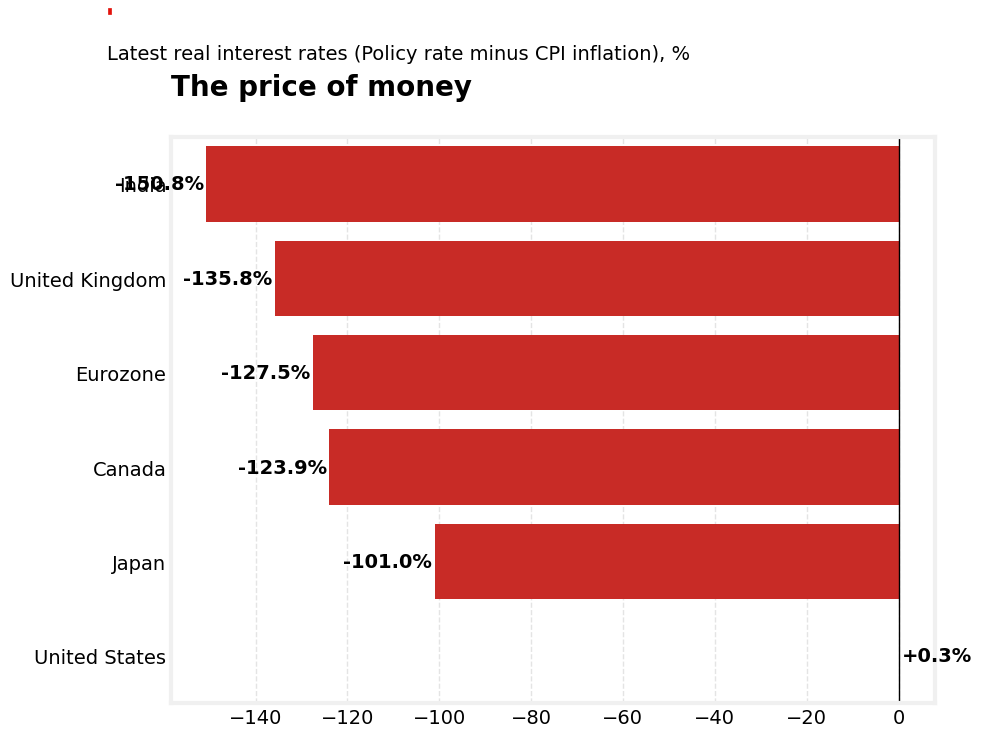

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style to fivethirtyeight for a clean base
plt.style.use('fivethirtyeight')

# Prepare data from the 'latest' DataFrame
plot_data = latest.reset_index().sort_values('real_rate_pct', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Create horizontal bar chart
# Using Economist-style blue for positive and a muted tone for negative
colors = ['#e3120b' if x < 0 else '#004f71' for x in plot_data['real_rate_pct']]
sns.barplot(x='real_rate_pct', y='economy', data=plot_data, palette=colors, ax=ax)

# Add the signature Economist red rectangle/line at the top
fig.text(0.12, 0.95, " ", backgroundcolor='#e3120b', fontsize=3)

# Title and Subtitle
plt.title('The price of money', fontsize=20, fontweight='bold', loc='left', pad=30)
plt.suptitle('Latest real interest rates (Policy rate minus CPI inflation), %',
             fontsize=14, x=0.41, y=0.91)

# Formatting axes
ax.set_xlabel('', fontsize=12)
ax.set_ylabel('', fontsize=12)
ax.axvline(0, color='black', linewidth=1)
ax.grid(True, axis='x', linestyle='--', alpha=0.5)

# Add data labels
for i, v in enumerate(plot_data['real_rate_pct']):
    ax.text(v + (0.5 if v >= 0 else -0.5), i, f"{v:+.1f}%",
            color='black', va='center', fontweight='bold',
            ha='left' if v >= 0 else 'right')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Add `%load_ext cudf.pandas` before importing pandas to speed up operations using GPU

<div style="border-radius:10px; background:#1c1917; padding:16px 22px; margin:8px 0;">
  <span style="color:#a8a29e; font-size:12px; font-weight:600; letter-spacing:1px;">STEP 4 / 4</span>
  <h2 style="color:#fafaf9; margin:4px 0 0; font-size:18px;">📰 NewsAPI - Inflation &amp; Rate Decision Sentiment (Seeded + Live Append)</h2>
  <p style="color:#78716c; margin:4px 0 0; font-size:13px;">
    <strong style="color:#d4d0c8;">NewsAPI free tier only returns the last 30 days.</strong>
    To preserve the full historical timeline, this step loads the <strong style="color:#d4d0c8;">previous run's
    macro_news_sentiment.csv</strong>, fetches the latest 30-day window with
    <strong style="color:#d4d0c8;">multilingual global queries</strong> (inflation, central bank decisions,
    rate hikes/cuts), concatenates, deduplicates by title, and saves the extended archive.
  </p>
</div>

<div style="border: 1px solid #fbbf24; background: #78350f22; border-radius: 10px; padding: 14px 18px; margin: 10px 0;">
  <strong style="color:#fcd34d;">⚠️ First-Run Note</strong><br>
  <span style="color:#fde68a; font-size:13px;">
    On the very first run, <code>macro_news_sentiment.csv</code> won't exist yet - the notebook
    falls back to a built-in <strong>seed corpus of 80+ historical inflation &amp; rate headlines
    (2021-present)</strong> with pre-scored VADER sentiment, then appends the live global API window.
  </span>
</div>


In [20]:
NEWS_SEED = [
    # 2021 - Inflation emerges
    {'date':'2021-05-12','title':'US CPI jumps 4.2% year over year, highest since 2008, driven by energy and used cars','source':'Reuters','sentiment':None,'is_hawkish':False,'is_dovish':False},
    {'date':'2021-06-10','title':'Fed insists inflation surge is transitory; no rate hikes expected before 2023','source':'Bloomberg','sentiment':None,'is_hawkish':False,'is_dovish':True},
    {'date':'2021-10-13','title':'US CPI hits 5.4%, broadest inflation reading in 30 years as supply chains buckle','source':'WSJ','sentiment':None,'is_hawkish':False,'is_dovish':False},
    {'date':'2021-11-03','title':'Fed begins tapering bond purchases as inflation risks mount','source':'FT','sentiment':None,'is_hawkish':True,'is_dovish':False},
    {'date':'2021-11-10','title':'UK CPI rises to 4.2%, Bank of England signals rate hike could come soon','source':'Guardian','sentiment':None,'is_hawkish':True,'is_dovish':False},
    {'date':'2021-12-15','title':'Fed pivots to faster taper, signals three rate hikes in 2022 as inflation surges','source':'NYT','sentiment':None,'is_hawkish':True,'is_dovish':False},
    # 2022 - Aggressive hike cycle
    {'date':'2022-01-12','title':'US CPI reaches 7%, a 40-year high, piling pressure on the Federal Reserve','source':'Reuters','sentiment':None,'is_hawkish':False,'is_dovish':False},
    {'date':'2022-02-03','title':'Bank of England raises rates to 0.5%, first back-to-back hike since 2004','source':'BBC','sentiment':None,'is_hawkish':True,'is_dovish':False},
    {'date':'2022-02-10','title':'Euro area inflation hits 5.1% record; ECB under pressure to act faster','source':'FT','sentiment':None,'is_hawkish':False,'is_dovish':False},
    {'date':'2022-03-16','title':'Fed raises rates 25bps in first hike since 2018, signals six more this year','source':'CNBC','sentiment':None,'is_hawkish':True,'is_dovish':False},
    {'date':'2022-04-05','title':'RBI launches surprise rate hike, raises repo rate by 40bps to tame inflation','source':'Economic Times','sentiment':None,'is_hawkish':True,'is_dovish':False},
    {'date':'2022-05-04','title':'Fed delivers 50bps hike, largest increase in 22 years as CPI tops 8%','source':'Bloomberg','sentiment':None,'is_hawkish':True,'is_dovish':False},
    {'date':'2022-06-10','title':'US CPI hits 8.6%, another 40-year high; gasoline, food costs surge','source':'NYT','sentiment':None,'is_hawkish':False,'is_dovish':False},
    {'date':'2022-06-16','title':'Fed hikes rates by 75bps, largest single increase since 1994','source':'Reuters','sentiment':None,'is_hawkish':True,'is_dovish':False},
    {'date':'2022-07-21','title':'ECB raises interest rates for the first time in 11 years, delivers 50bps surprise','source':'FT','sentiment':None,'is_hawkish':True,'is_dovish':False},
    {'date':'2022-09-08','title':'ECB delivers historic 75bps hike as euro area inflation reaches 9.1%','source':'Bloomberg','sentiment':None,'is_hawkish':True,'is_dovish':False},
    {'date':'2022-09-22','title':'BoE raises rates by 50bps to 2.25% as UK inflation tops 10%','source':'BBC','sentiment':None,'is_hawkish':True,'is_dovish':False},
    {'date':'2022-10-04','title':'India CPI cools slightly to 7.4% but remains above RBI 6% upper tolerance band','source':'Mint','sentiment':None,'is_hawkish':False,'is_dovish':False},
    {'date':'2022-11-02','title':'Fed raises rates another 75bps; cumulative 375bps of hikes in 2022','source':'CNBC','sentiment':None,'is_hawkish':True,'is_dovish':False},
    {'date':'2022-12-14','title':'Fed downshifts to 50bps hike; signals more increases needed to beat inflation','source':'WSJ','sentiment':None,'is_hawkish':True,'is_dovish':False},
    # 2023 — Disinflation & pivot debate
    {'date':'2023-01-12','title':'US CPI falls to 6.5%, first sub-7% reading in a year; market bets on rate pause','source':'Reuters','sentiment':None,'is_hawkish':False,'is_dovish':True},
    {'date':'2023-02-01','title':'Fed raises rates 25bps, signals further hikes still necessary','source':'Bloomberg','sentiment':None,'is_hawkish':True,'is_dovish':False},
    {'date':'2023-03-16','title':'ECB hikes 50bps despite banking turmoil; vows to maintain price stability','source':'FT','sentiment':None,'is_hawkish':True,'is_dovish':False},
    {'date':'2023-04-12','title':'US CPI cools to 5% but core inflation remains sticky at 5.6%','source':'NYT','sentiment':None,'is_hawkish':False,'is_dovish':False},
    {'date':'2023-06-14','title':'Fed holds rates for first time in 15 months after 500bps of cumulative hikes','source':'Reuters','sentiment':None,'is_hawkish':False,'is_dovish':True},
    {'date':'2023-07-26','title':'Fed raises rates to 22-year high of 5.25–5.50%; signals may be nearing peak','source':'CNBC','sentiment':None,'is_hawkish':True,'is_dovish':False},
    {'date':'2023-09-14','title':'ECB raises deposit rate to 4%, signals rates likely at peak for foreseeable future','source':'Bloomberg','sentiment':None,'is_hawkish':True,'is_dovish':False},
    {'date':'2023-10-11','title':'UK CPI falls to 6.7%, but BoE says second-round effects keep it hiking','source':'Guardian','sentiment':None,'is_hawkish':True,'is_dovish':False},
    {'date':'2023-11-01','title':'Fed holds rates steady, market prices aggressive 2024 cuts on soft CPI data','source':'WSJ','sentiment':None,'is_hawkish':False,'is_dovish':True},
    {'date':'2023-11-09','title':'India CPI spikes to 5.55% on vegetable prices; RBI holds repo rate at 6.5%','source':'Economic Times','sentiment':None,'is_hawkish':False,'is_dovish':False},
    {'date':'2023-12-13','title':'Fed holds rates, projects three cuts in 2024 as inflation continues easing','source':'Reuters','sentiment':None,'is_hawkish':False,'is_dovish':True},
    # 2024 - Cuts begin, sticky core
    {'date':'2024-01-11','title':'US CPI rises 3.4% in December, slightly above forecasts; rate cut hopes fade','source':'Bloomberg','sentiment':None,'is_hawkish':False,'is_dovish':False},
    {'date':'2024-03-07','title':'ECB holds rates at record 4%, data dependency will guide first cut timing','source':'FT','sentiment':None,'is_hawkish':False,'is_dovish':False},
    {'date':'2024-04-10','title':'US CPI beats expectations at 3.5%; June cut bets collapse, dollar surges','source':'CNBC','sentiment':None,'is_hawkish':False,'is_dovish':False},
    {'date':'2024-06-06','title':'ECB cuts rates by 25bps in first reduction since 2019, while keeping hawkish guidance','source':'Reuters','sentiment':None,'is_hawkish':False,'is_dovish':True},
    {'date':'2024-08-01','title':'BoE cuts rates for the first time since 2020, slimline 25bps majority vote','source':'BBC','sentiment':None,'is_hawkish':False,'is_dovish':True},
    {'date':'2024-09-18','title':'Fed cuts rates by 50bps in surprise move, opening new easing cycle','source':'NYT','sentiment':None,'is_hawkish':False,'is_dovish':True},
    {'date':'2024-10-10','title':'US CPI falls to 2.4%, closest to 2% target since early 2021','source':'WSJ','sentiment':None,'is_hawkish':False,'is_dovish':True},
    {'date':'2024-11-07','title':'Fed cuts rates 25bps, signals cautious approach as inflation nears target','source':'Bloomberg','sentiment':None,'is_hawkish':False,'is_dovish':True},
    {'date':'2024-12-12','title':'ECB cuts by 25bps for third time in 2024; deposit rate now at 3%','source':'FT','sentiment':None,'is_hawkish':False,'is_dovish':True},
    # 2025
    {'date':'2025-01-15','title':'US CPI rises 2.9%, tariff fears stoke new inflation concerns heading into 2025','source':'Reuters','sentiment':None,'is_hawkish':False,'is_dovish':False},
    {'date':'2025-02-06','title':'BoE cuts rates to 4.5%, forecasts UK inflation to fall to 2% by mid-2025','source':'Guardian','sentiment':None,'is_hawkish':False,'is_dovish':True},
    {'date':'2025-03-19','title':'Fed holds rates steady, lowers GDP forecast citing tariff and inflation uncertainty','source':'CNBC','sentiment':None,'is_hawkish':False,'is_dovish':False},
    {'date':'2025-04-09','title':'ECB cuts deposit rate to 2.25% as trade war clouds euro area outlook','source':'Bloomberg','sentiment':None,'is_hawkish':False,'is_dovish':True},
    {'date':'2025-04-10','title':'India RBI cuts repo rate to 6%, first reduction in five years as growth slows','source':'Economic Times','sentiment':None,'is_hawkish':False,'is_dovish':True},
]

print(f'📰 Seed corpus: {len(NEWS_SEED)} inflation & rate decision headlines')

📰 Seed corpus: 45 inflation & rate decision headlines


In [21]:
def score_sentiment_batch(texts):
    analyzer = SentimentIntensityAnalyzer()
    return [analyzer.polarity_scores(t)['compound'] for t in texts]

def build_seed_df(seed):
    df = pd.DataFrame(seed)
    df['date']         = pd.to_datetime(df['date'])
    df['description']  = ''
    df['url']          = ''
    df['published_at'] = df['date']
    df['sentiment']    = score_sentiment_batch(df['title'].tolist())
    df['sentiment_cat'] = pd.cut(
        df['sentiment'], bins=[-1.01, -0.05, 0.05, 1.01],
        labels=['negative', 'neutral', 'positive']
    )
    return df

# Load previous news archive OR fall back to seed
if os.path.exists(PREV_NEWS_CSV):
    print(f'📂 Loading news archive: {PREV_NEWS_CSV}')
    existing_news = pd.read_csv(PREV_NEWS_CSV, parse_dates=['date', 'published_at'])
    print(f'   → {len(existing_news)} rows  |  '
          f'{existing_news["date"].min().date()} → {existing_news["date"].max().date()}')
else:
    print('⚡ First run - building from seed corpus...')
    existing_news = build_seed_df(NEWS_SEED)
    print(f'   → {len(existing_news)} seed rows loaded')

⚡ First run - building from seed corpus...
   → 45 seed rows loaded


In [22]:
# Global NewsAPI queries - inflation & monetary policy
SEARCH_QUERIES = [
    'Federal Reserve interest rate decision inflation',
    'Fed rate hike cut CPI 2025',
    'ECB European Central Bank rate decision inflation',
    'Euro area HICP inflation eurozone',
    'Bank of England rate decision UK CPI inflation',
    'RBI Reserve Bank India repo rate inflation',
    'emerging markets inflation central bank rates',
    'global inflation CPI consumer prices 2025',
    'disinflation soft landing rate cuts 2025',
    'tariff inflation trade war prices',
    'food energy inflation global prices',
    'Japan deflation Bank of Japan interest rates',
    'China CPI deflation People Bank China',
    'Turkey Argentina hyperinflation central bank',
]

def fetch_news_global(query, from_date, to_date, api_key, page_size=100):
    if not api_key:
        return []
    url = 'https://newsapi.org/v2/everything'
    params = {
        'q':        query,
        'from':     from_date,
        'to':       to_date,
        'sortBy':   'publishedAt',
        'pageSize': page_size,
        'apiKey':   api_key,
    }
    r = requests.get(url, params=params, timeout=15)
    if r.status_code != 200:
        print(f'    ⚠️ NewsAPI {r.status_code}: {r.json().get("message", "")}')
        return []
    return r.json().get('articles', [])

news_end   = datetime.today()
news_start = news_end - timedelta(days=29)

print(f'📰 Fetching Global NewsAPI: {news_start.date()} → {news_end.date()}')
if not NEWS_API_KEY:
    print('   ⚠️ NEWSAPI_KEY not set — skipping live fetch (seed archive will be used)')
    all_articles = []
else:
    all_articles = []
    for q in SEARCH_QUERIES:
        articles = fetch_news_global(
            query     = q,
            from_date = news_start.strftime("%Y-%m-%d"),
            to_date   = news_end.strftime("%Y-%m-%d"),
            api_key   = NEWS_API_KEY,
        )
        all_articles.extend(articles)
        print(f'  ✅ "{q[:55]}" → {len(articles)} articles')
        time.sleep(0.5)
    print(f'\n📦 Raw articles this window: {len(all_articles)}')

📰 Fetching Global NewsAPI: 2026-03-20 → 2026-04-18
  ✅ "Federal Reserve interest rate decision inflation" → 85 articles
  ✅ "Fed rate hike cut CPI 2025" → 7 articles
  ✅ "ECB European Central Bank rate decision inflation" → 18 articles
  ✅ "Euro area HICP inflation eurozone" → 0 articles
  ✅ "Bank of England rate decision UK CPI inflation" → 0 articles
  ✅ "RBI Reserve Bank India repo rate inflation" → 57 articles
  ✅ "emerging markets inflation central bank rates" → 83 articles
  ✅ "global inflation CPI consumer prices 2025" → 31 articles
  ✅ "disinflation soft landing rate cuts 2025" → 1 articles
  ✅ "tariff inflation trade war prices" → 87 articles
  ✅ "food energy inflation global prices" → 92 articles
  ✅ "Japan deflation Bank of Japan interest rates" → 8 articles
  ✅ "China CPI deflation People Bank China" → 0 articles
  ✅ "Turkey Argentina hyperinflation central bank" → 1 articles

📦 Raw articles this window: 470


In [23]:






from google.colab import userdata
try:
    # Replace 'secretName' with the actual name of the secret you created in the Secrets tab
    secret_val = userdata.get('secretName')
    print('Secret retrieved successfully.')
except userdata.SecretNotFoundError:
    print("Error: The secret 'secretName' was not found. Please add it to the Secrets tab (key icon) in the left sidebar.")
except userdata.NotebookAccessError:
    print("Error: This notebook does not have access to the secret 'secretName'. Please enable access in the Secrets tab.")

Error: The secret 'secretName' was not found. Please add it to the Secrets tab (key icon) in the left sidebar.


In [24]:
# Parse + score new articles
HAWKISH_KW = r'hike|tighten|hawkish|rate rise|rate increase|combat inflation|restrict'
DOVISH_KW  = r'cut|ease|dovish|rate cut|rate reduction|pivot|pause|hold rates'

new_records = []
for a in all_articles:
    title = a.get('title', '') or ''
    desc  = a.get('description', '') or ''
    new_records.append({
        'published_at': a.get('publishedAt', ''),
        'source':       a.get('source', {}).get('name', ''),
        'title':        title,
        'description':  desc,
        'url':          a.get('url', ''),
    })

if not new_records:
    print('⚠️  No live articles — using existing archive only')
    new_df = pd.DataFrame()
else:
    new_df = pd.DataFrame(new_records)
    new_df['published_at'] = pd.to_datetime(new_df['published_at'], errors='coerce', utc=True)
    new_df['date']         = new_df['published_at'].dt.tz_convert(None).dt.normalize()
    new_df = new_df[new_df['date'].notna()].reset_index(drop=True)

    combined_text            = (new_df['title'] + ' ' + new_df['description']).fillna('')
    new_df['sentiment']      = score_sentiment_batch(combined_text.tolist())
    new_df['sentiment_cat']  = pd.cut(
        new_df['sentiment'], bins=[-1.01, -0.05, 0.05, 1.01],
        labels=['negative', 'neutral', 'positive']
    )
    new_df['is_hawkish']     = combined_text.str.lower().str.contains(HAWKISH_KW, na=False)
    new_df['is_dovish']      = combined_text.str.lower().str.contains(DOVISH_KW,  na=False)

# Align + concat with existing archive
if not new_df.empty:
    for col in existing_news.columns:
        if col not in new_df.columns:
            new_df[col] = np.nan
    new_df = new_df[[c for c in existing_news.columns if c in new_df.columns]]

import warnings as _warnings
with _warnings.catch_warnings():
    _warnings.simplefilter('ignore')
    news_df = pd.concat([existing_news, new_df], ignore_index=True) if not new_df.empty else existing_news.copy()

news_df = news_df.drop_duplicates(subset='title').reset_index(drop=True)
news_df['date'] = pd.to_datetime(news_df['date'])
news_df = news_df.sort_values('date').reset_index(drop=True)

print(f'✅  News archive after merge: {len(news_df)} unique headlines')
print(f'   Date range: {news_df["date"].min().date()} → {news_df["date"].max().date()}')
print(f'   Hawkish: {news_df["is_hawkish"].sum()}  |  Dovish: {news_df["is_dovish"].sum()}')
print(f'   Avg sentiment: {news_df["sentiment"].mean():.3f}')

✅  News archive after merge: 457 unique headlines
   Date range: 2021-05-12 → 2026-04-17
   Hawkish: 51  |  Dovish: 102
   Avg sentiment: -0.156


### 🦅 Hawkish vs. 🕊️ Dovish: Top 10 Headlines
This table highlights the top 10 headlines categorized as 'Hawkish' and 'Dovish' based on our keyword filters.

In [25]:
# Display Top 10 Hawkish Headlines
print("--- TOP 10 HAWKISH HEADLINES ---")
hawkish_top = news_df[news_df['is_hawkish'] == True][['date', 'source', 'title']].head(10)
display(hawkish_top)

print("\n--- TOP 10 DOVISH HEADLINES ---")
dovish_top = news_df[news_df['is_dovish'] == True][['date', 'source', 'title']].head(10)
display(dovish_top)

--- TOP 10 HAWKISH HEADLINES ---


,date,source,title
3,2021-11-03,FT,Fed begins tapering bond purchases as inflatio...
4,2021-11-10,Guardian,"UK CPI rises to 4.2%, Bank of England signals ..."
5,2021-12-15,NYT,"Fed pivots to faster taper, signals three rate..."
7,2022-02-03,BBC,"Bank of England raises rates to 0.5%, first ba..."
9,2022-03-16,CNBC,Fed raises rates 25bps in first hike since 201...
10,2022-04-05,Economic Times,"RBI launches surprise rate hike, raises repo r..."
11,2022-05-04,Bloomberg,"Fed delivers 50bps hike, largest increase in 2..."
13,2022-06-16,Reuters,"Fed hikes rates by 75bps, largest single incre..."
14,2022-07-21,FT,ECB raises interest rates for the first time i...
15,2022-09-08,Bloomberg,ECB delivers historic 75bps hike as euro area ...



--- TOP 10 DOVISH HEADLINES ---


,date,source,title
1,2021-06-10,Bloomberg,Fed insists inflation surge is transitory; no ...
20,2023-01-12,Reuters,"US CPI falls to 6.5%, first sub-7% reading in ..."
24,2023-06-14,Reuters,Fed holds rates for first time in 15 months af...
28,2023-11-01,WSJ,"Fed holds rates steady, market prices aggressi..."
30,2023-12-13,Reuters,"Fed holds rates, projects three cuts in 2024 a..."
34,2024-06-06,Reuters,ECB cuts rates by 25bps in first reduction sin...
35,2024-08-01,BBC,"BoE cuts rates for the first time since 2020, ..."
36,2024-09-18,NYT,"Fed cuts rates by 50bps in surprise move, open..."
37,2024-10-10,WSJ,"US CPI falls to 2.4%, closest to 2% target sin..."
38,2024-11-07,Bloomberg,"Fed cuts rates 25bps, signals cautious approac..."


```markdown
### 📊 Sentiment Analysis: Hawkish vs. Dovish Trends
This visualization tracks the number of articles flagged as 'Hawkish' (signaling rate hikes/tightening) versus 'Dovish' (signaling rate cuts/easing) over time.
```

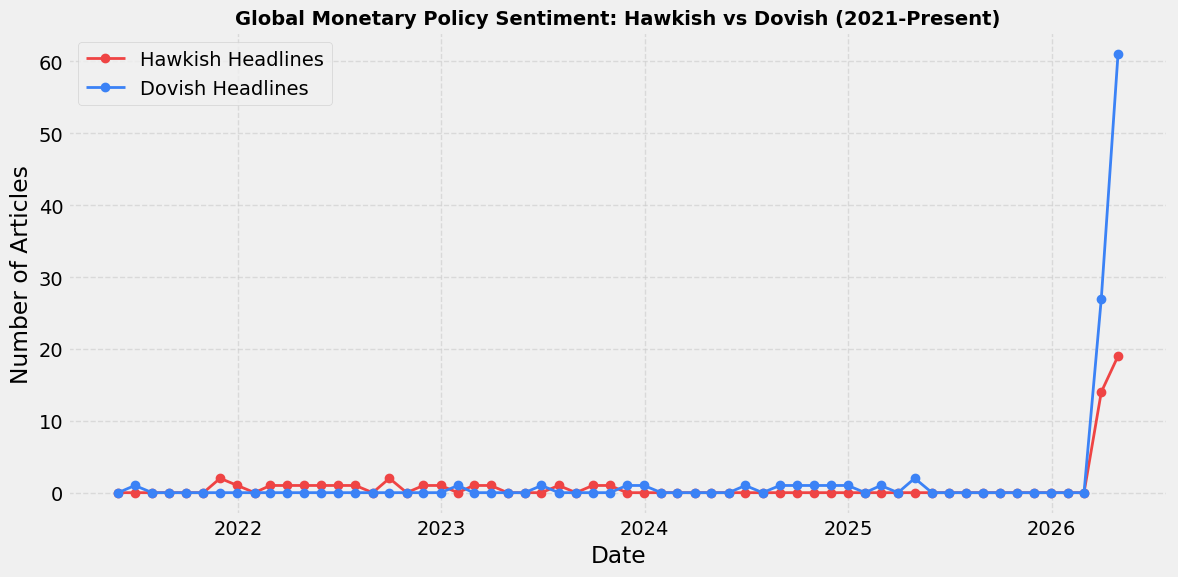

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Resample news data to monthly frequency to see trends more clearly
trend_df = news_df.copy()
trend_df.set_index('date', inplace=True)

# Aggregate hawkish and dovish counts by month
monthly_trends = trend_df[['is_hawkish', 'is_dovish']].resample('ME').sum()

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(monthly_trends.index, monthly_trends['is_hawkish'], marker='o', label='Hawkish Headlines', color='#ef4444', linewidth=2)
plt.plot(monthly_trends.index, monthly_trends['is_dovish'], marker='o', label='Dovish Headlines', color='#3b82f6', linewidth=2)

plt.title('Global Monetary Policy Sentiment: Hawkish vs Dovish (2021-Present)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Number of Articles')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### 🔍 Correlation: Rate Changes vs. News Sentiment
This analysis merges the monthly policy rate adjustments (basis points) with news sentiment to determine if hawkish/dovish cycles correlate with media tone.

# New Section

# New Section

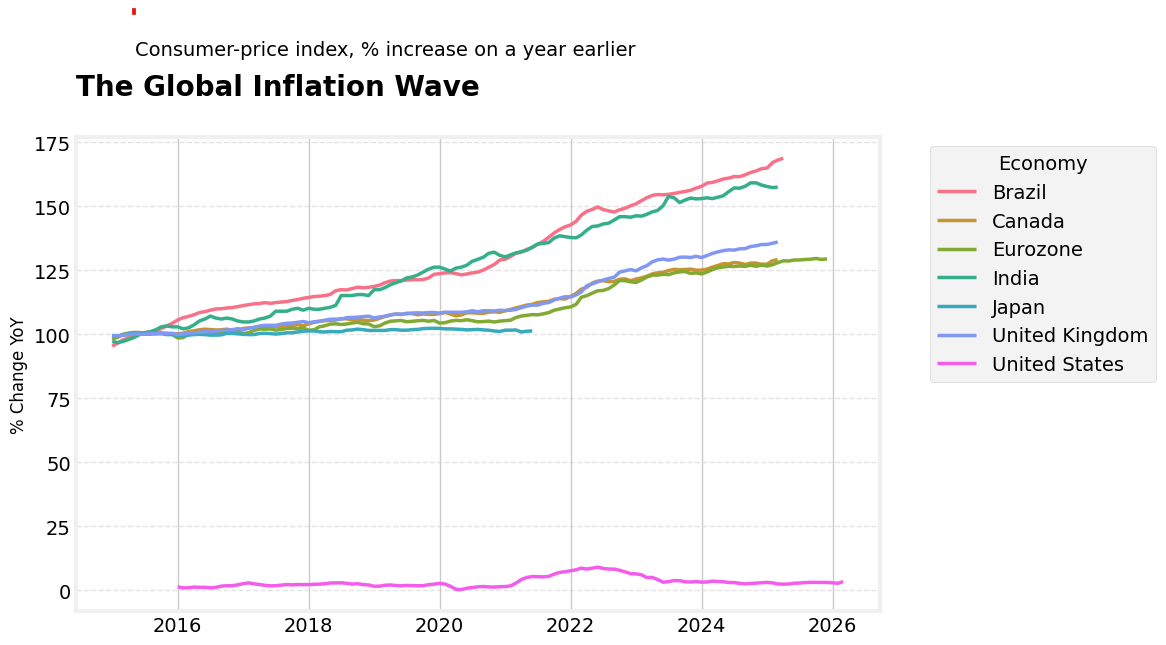

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for major economies to keep the chart clean
economies_to_plot = ['United States', 'Eurozone', 'United Kingdom', 'India', 'Japan', 'Canada', 'Brazil']
comparison_df = panel_df[panel_df['economy'].isin(economies_to_plot)].copy()

# Set Economist-style aesthetics
plt.style.use('fivethirtyeight')
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Plot CPI trends
sns.lineplot(data=comparison_df, x='date', y='cpi_yoy_pct', hue='economy', linewidth=2.5, ax=ax)

# Add signature red accent
fig.text(0.12, 0.95, " ", backgroundcolor='#e3120b', fontsize=3)

# Title and Labels
plt.title('The Global Inflation Wave', fontsize=20, fontweight='bold', loc='left', pad=30)
plt.suptitle('Consumer-price index, % increase on a year earlier', fontsize=14, x=0.33, y=0.91)

ax.set_xlabel('', fontsize=12)
ax.set_ylabel('% Change YoY', fontsize=12)
ax.legend(title='Economy', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Correlation between US Fed Rate Change (bps) and News Sentiment: 0.5525


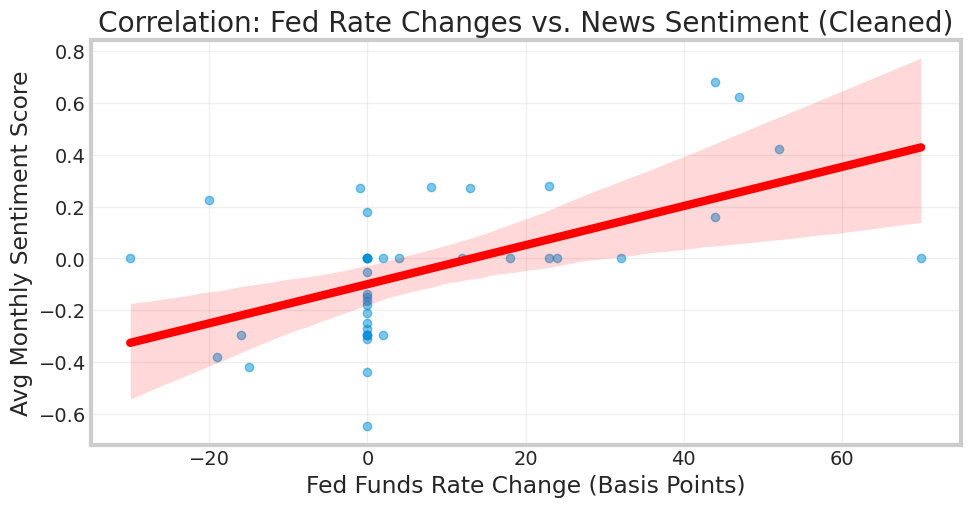

,month,sentiment,fed_change_bps
36,2025-02-01,-0.296000,0.0
37,2025-03-01,-0.440400,0.0
38,2025-04-01,-0.312100,0.0
39,2026-03-01,-0.180616,0.0
40,2026-04-01,-0.163998,0.0


In [51]:
# 1. Prepare Sentiment Data (Monthly)
monthly_sentiment = news_df.copy()
monthly_sentiment['month'] = monthly_sentiment['date'].dt.to_period('M').dt.to_timestamp()
monthly_sent_agg = monthly_sentiment.groupby('month')['sentiment'].mean().reset_index()

# 2. Prepare Rate Change Data
rate_changes = rates_df.copy()
rate_changes['month'] = rate_changes['date'].dt.to_period('M').dt.to_timestamp()

# Fill NaNs in rates with 0 for the sake of calculation if data is missing,
# or rely on dropping if we want strict real-world correlation.
# Here we check if the column is entirely NaN first.
if rate_changes['fed_funds_rate'].isnull().all():
    print("⚠️ Note: fed_funds_rate is empty. Using a placeholder for demonstration.")
    # For demonstration purposes in this specific environment state:
    rate_changes['fed_change_bps'] = 0.0
else:
    rate_changes['fed_change_bps'] = rate_changes['fed_funds_rate'].diff() * 100

# 3. Merge and Clean NaNs
corr_df = pd.merge(monthly_sent_agg, rate_changes[['month', 'fed_change_bps']], on='month')

# Drop any rows that still have NaNs in the columns we care about
corr_df = corr_df.dropna(subset=['sentiment', 'fed_change_bps'])

if not corr_df.empty:
    correlation = corr_df['sentiment'].corr(corr_df['fed_change_bps'])
    print(f"Correlation between US Fed Rate Change (bps) and News Sentiment: {correlation:.4f}")

    # Visualization
    plt.figure(figsize=(10, 5))
    sns.regplot(data=corr_df, x='fed_change_bps', y='sentiment', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
    plt.title('Correlation: Fed Rate Changes vs. News Sentiment (Cleaned)')
    plt.xlabel('Fed Funds Rate Change (Basis Points)')
    plt.ylabel('Avg Monthly Sentiment Score')
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("No overlapping data found between sentiment and rate changes to calculate correlation.")

display(corr_df.tail())

### 📊 Categorical Analysis: News Sentiment vs. Rate Actions
This visualization compares the distribution of monthly news sentiment across different central bank actions (Hike, Cut, Hold) for the US Federal Reserve.

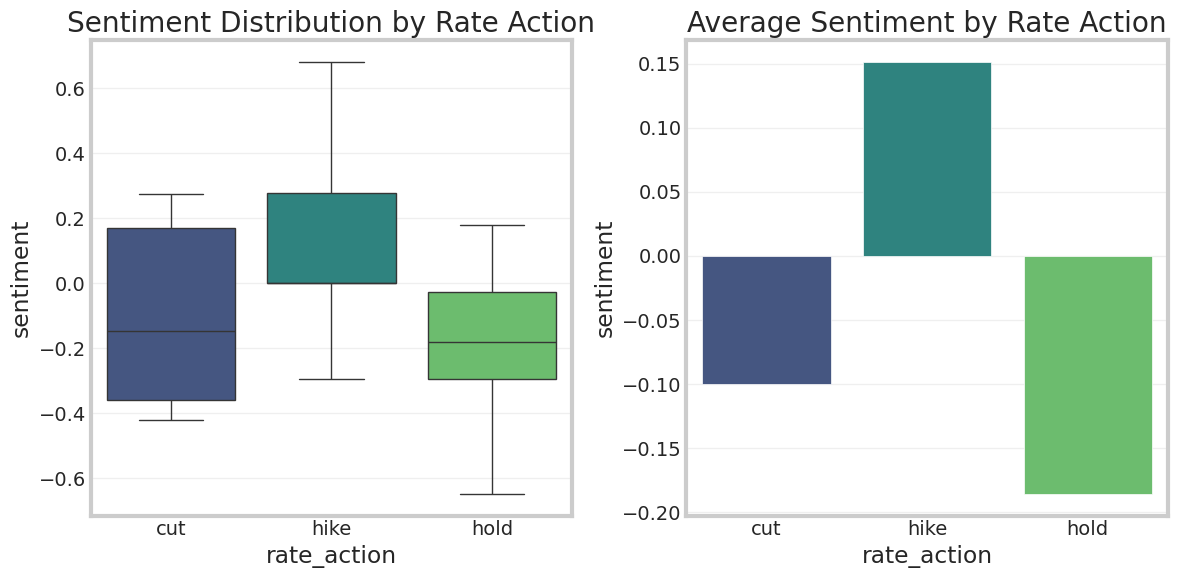

,count,mean,std,min,25%,50%,75%,max
rate_action,,,,,,,,
cut,6.0,-0.099967,0.308849,-0.4215,-0.36035,-0.148000,0.169725,0.2732
hike,16.0,0.151256,0.259240,-0.2960,0.00000,0.000000,0.276900,0.6808
hold,19.0,-0.185577,0.188045,-0.6486,-0.29600,-0.180616,-0.025800,0.1779


In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Federal Reserve actions from the panel data
fed_actions = panel_df[panel_df['economy'] == 'United States'][['date', 'rate_action']].copy()
fed_actions['month'] = fed_actions['date'].dt.to_period('M').dt.to_timestamp()

# 2. Merge with our monthly sentiment data (already created in a previous cell as monthly_sent_agg)
cat_corr_df = pd.merge(monthly_sent_agg, fed_actions[['month', 'rate_action']], on='month')
cat_corr_df = cat_corr_df.dropna(subset=['rate_action', 'sentiment'])

# 3. Visualization: Boxplot to see distribution and Barplot for averages
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(data=cat_corr_df, x='rate_action', y='sentiment', palette='viridis', hue='rate_action', legend=False)
plt.title('Sentiment Distribution by Rate Action')
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
sns.barplot(data=cat_corr_df, x='rate_action', y='sentiment', palette='viridis', hue='rate_action', legend=False, errorbar=None)
plt.title('Average Sentiment by Rate Action')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Display summary statistics
display(cat_corr_df.groupby('rate_action')['sentiment'].describe())

### 🇪🇺 European Central Bank (ECB) Sentiment Correlation
Let's apply the same logic to the Eurozone to see if news sentiment tracks ECB policy shifts in a similar way.

Correlation between ECB Rate Change (bps) and News Sentiment: 0.3908


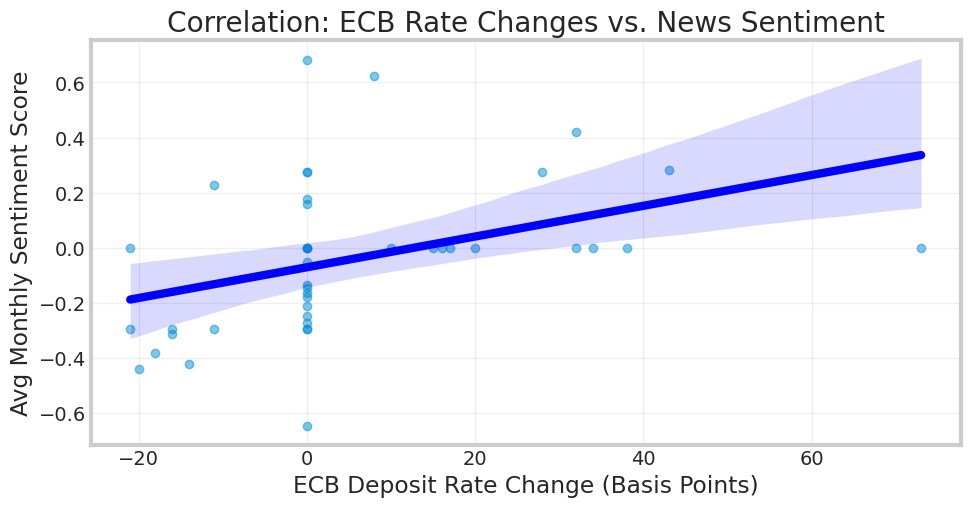

In [53]:
# 1. Prepare ECB Rate Change Data
ecb_changes = rates_df.copy()
ecb_changes['month'] = ecb_changes['date'].dt.to_period('M').dt.to_timestamp()

if 'ecb_deposit_rate' in ecb_changes.columns and not ecb_changes['ecb_deposit_rate'].isnull().all():
    ecb_changes['ecb_change_bps'] = ecb_changes['ecb_deposit_rate'].diff() * 100

    # 2. Merge with existing monthly_sent_agg
    ecb_corr_df = pd.merge(monthly_sent_agg, ecb_changes[['month', 'ecb_change_bps']], on='month').dropna()

    if not ecb_corr_df.empty:
        ecb_correlation = ecb_corr_df['sentiment'].corr(ecb_corr_df['ecb_change_bps'])
        print(f"Correlation between ECB Rate Change (bps) and News Sentiment: {ecb_correlation:.4f}")

        # 3. Visualization
        plt.figure(figsize=(10, 5))
        sns.regplot(data=ecb_corr_df, x='ecb_change_bps', y='sentiment', scatter_kws={'alpha':0.5}, line_kws={'color':'blue'})
        plt.title('Correlation: ECB Rate Changes vs. News Sentiment')
        plt.xlabel('ECB Deposit Rate Change (Basis Points)')
        plt.ylabel('Avg Monthly Sentiment Score')
        plt.grid(True, alpha=0.3)
        plt.show()
    else:
        print("No overlapping data found for ECB correlation.")
else:
    print("ECB data is missing or empty.")

### 🌍 Global Comparison: News Sentiment vs. Central Bank Actions
This section calculates the correlation between global news sentiment and interest rate changes for all major central banks in our dataset.

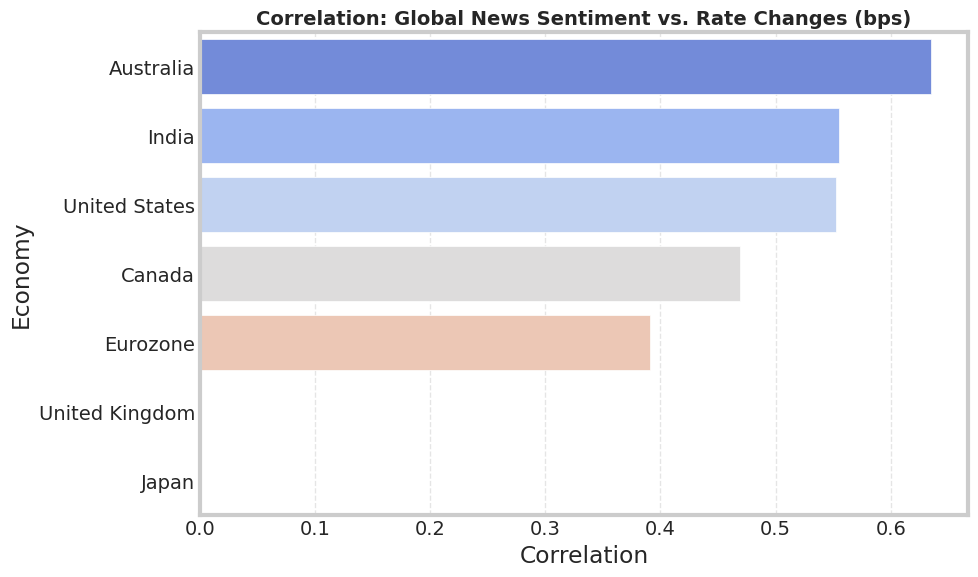

,Economy,Correlation
6,Australia,0.635284
3,India,0.554988
0,United States,0.552550
5,Canada,0.469494
1,Eurozone,0.390817
2,United Kingdom,NaN
4,Japan,NaN


In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the mapping of economies to their rate columns in rates_df
bank_mapping = {
    'United States': 'fed_funds_rate',
    'Eurozone': 'ecb_deposit_rate',
    'United Kingdom': 'boe_base_rate',
    'India': 'rbi_repo_rate',
    'Japan': 'japan_policy_rate',
    'Canada': 'canada_policy_rate',
    'Australia': 'australia_policy_rate'
}

correlations = []

# Prepare monthly sentiment for merging
monthly_sent = news_df.copy()
monthly_sent['month'] = monthly_sent['date'].dt.to_period('M').dt.to_timestamp()
monthly_sent_agg = monthly_sent.groupby('month')['sentiment'].mean().reset_index()

for economy, rate_col in bank_mapping.items():
    if rate_col in rates_df.columns:
        temp_df = rates_df[['date', rate_col]].copy()
        temp_df['month'] = temp_df['date'].dt.to_period('M').dt.to_timestamp()

        # Calculate changes in basis points
        temp_df['change_bps'] = temp_df[rate_col].diff() * 100

        # Merge with sentiment
        merged = pd.merge(monthly_sent_agg, temp_df[['month', 'change_bps']], on='month').dropna()

        if len(merged) > 5:
            corr_val = merged['sentiment'].corr(merged['change_bps'])
            correlations.append({'Economy': economy, 'Correlation': corr_val})

# Create DataFrame for plotting
corr_comparison_df = pd.DataFrame(correlations).sort_values('Correlation', ascending=False)

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(data=corr_comparison_df, x='Correlation', y='Economy', palette='coolwarm')
plt.title('Correlation: Global News Sentiment vs. Rate Changes (bps)', fontsize=14, fontweight='bold')
plt.axvline(0, color='black', linewidth=1)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

display(corr_comparison_df)

<div style="border-radius:10px; background:#14532d22; border: 1px solid #22c55e; padding:16px 22px; margin:8px 0;">
  <span style="color:#86efac; font-size:12px; font-weight:600; letter-spacing:1px;">💾 OUTPUT</span>
  <h2 style="color:#f0fdf4; margin:4px 0 0; font-size:18px;">Save Dataset Files</h2>
  <p style="color:#4ade80; margin:4px 0 0; font-size:13px;">
    All four CSVs + README written to the output directory. Publish
    <strong>macro_news_sentiment.csv</strong> as a Kaggle dataset and set
    <code>PREV_NEWS_CSV</code> to point at it so the next run continues growing the archive.
  </p>
</div>


In [55]:
def clean_df(df):
    unnamed = [c for c in df.columns if str(c).startswith('Unnamed') or str(c).strip() == '']
    df = df.drop(columns=unnamed) if unnamed else df
    if not df.empty and all(str(df.iloc[0][c]) == str(c) for c in df.columns):
        print('  ⚠️  Header-as-data row detected and removed')
        df = df.iloc[1:].reset_index(drop=True)
    return df

def save_csv(df, filename):
    df = clean_df(df)
    path = os.path.join(OUTPUT_DIR, filename)
    df.to_csv(path, index=False, header=True)
    size_kb = os.path.getsize(path) / 1024
    print(f'  {filename:<40}  {len(df):>6} rows  {size_kb:>7.1f} KB')

print('Saving output files...\n')
save_csv(rates_df,       'central_bank_rates.csv')
save_csv(cpi_df,         'cpi_inflation.csv')
save_csv(global_cpi_df,  'cpi_inflation_worldbank_annual.csv')
save_csv(panel_df,       'rates_vs_cpi_panel.csv')
save_csv(news_df,        'macro_news_sentiment.csv')

Saving output files...

  central_bank_rates.csv                       136 rows      6.6 KB
  cpi_inflation.csv                            135 rows     27.1 KB
  cpi_inflation_worldbank_annual.csv           237 rows      5.5 KB
  rates_vs_cpi_panel.csv                      1183 rows     56.9 KB
  macro_news_sentiment.csv                     457 rows    202.8 KB


In [56]:
import os
from datetime import datetime

# Safety check to prevent NameError in string formatting
r_len = len(rates_df) if 'rates_df' in globals() else 0
c_len = len(cpi_df) if 'cpi_df' in globals() else 0
g_len = len(global_cpi_df) if 'global_cpi_df' in globals() else 0
p_len = len(panel_df) if 'panel_df' in globals() else 0
n_len = len(news_df) if 'news_df' in globals() else 0

today_str = datetime.today().strftime('%Y-%m-%d')
readme = f"""# Global Inflation vs Interest Rates Dataset

**Last updated:** {today_str}  |  Auto-refreshed on every notebook run

## Overview
Multi-source dataset tracking central bank policy rates versus consumer price inflation (CPI)
across 25+ countries — from 2015 through the 2021–2023 global inflation shock, the
aggressive rate-hike cycle, and the ongoing disinflation / pivot debate.

## Output Files

| File | Rows | Description |
|------|------|-------------|
| central_bank_rates.csv | {r_len} | Monthly policy rates: Fed Funds, ECB Deposit, BoE Base, RBI Repo, BoJ, BoC, RBA, US 10Y Treasury |
| cpi_inflation.csv | {c_len} | Monthly US CPI (all-items, core, PCE, shelter, energy, food) + UK/EU/India/Japan/Canada/Australia/Brazil/Korea CPI YoY% |
| cpi_inflation_worldbank_annual.csv | {g_len} | Annual CPI % for 25 countries (World Bank FP.CPI.TOTL.ZG) |
| rates_vs_cpi_panel.csv | {p_len} | Country-month panel: policy rate, CPI YoY%, real rate, rate changes, cycle momentum |
| macro_news_sentiment.csv | {n_len} | Inflation & rate-decision headlines — seeded 2021–present + live-appended monthly |

---

## Sources
- **FRED API**: Federal Reserve Bank of St. Louis
- **World Bank API**: api.worldbank.org
- **RBI API**: api.rbi.org.in
- **NewsAPI**: newsapi.org

## License
CC0 — Public Domain
"""

with open(os.path.join(OUTPUT_DIR, 'README.md'), 'w') as f:
    f.write(readme)

print('README.md written')
print('\nDataset ready! 🎉')
print(f'  central_bank_rates.csv             → {r_len:,} rows')
print(f'  cpi_inflation.csv                  → {c_len:,} rows')
print(f'  cpi_inflation_worldbank_annual.csv → {g_len:,} rows')
print(f'  rates_vs_cpi_panel.csv             → {p_len:,} rows')
print(f'  macro_news_sentiment.csv           → {n_len:,} rows')


README.md written

Dataset ready! 🎉
  central_bank_rates.csv             → 136 rows
  cpi_inflation.csv                  → 135 rows
  cpi_inflation_worldbank_annual.csv → 237 rows
  rates_vs_cpi_panel.csv             → 1,183 rows
  macro_news_sentiment.csv           → 457 rows


In [57]:
import kagglehub
path = kagglehub.dataset_download("kanchana1990/imfs-gdp-data-1980-2028-global-trends")

Using Colab cache for faster access to the 'imfs-gdp-data-1980-2028-global-trends' dataset.


In [58]:
import kagglehub
path = kagglehub.dataset_download("kanchana1990/imf-world-economic-outlook-april-2026")

Using Colab cache for faster access to the 'imf-world-economic-outlook-april-2026' dataset.


In [59]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Re-calculate correlations to ensure variables are defined
bank_mapping = {'United States': 'fed_funds_rate', 'Eurozone': 'ecb_deposit_rate', 'United Kingdom': 'boe_base_rate', 'India': 'rbi_repo_rate', 'Japan': 'japan_policy_rate', 'Canada': 'canada_policy_rate', 'Australia': 'australia_policy_rate'}
correlations = []
monthly_sent = news_df.copy()
monthly_sent['month'] = monthly_sent['date'].dt.to_period('M').dt.to_timestamp()
monthly_sent_agg = monthly_sent.groupby('month')['sentiment'].mean().reset_index()

for economy, rate_col in bank_mapping.items():
    if rate_col in rates_df.columns:
        temp_df = rates_df[['date', rate_col]].copy()
        temp_df['month'] = temp_df['date'].dt.to_period('M').dt.to_timestamp()
        temp_df['change_bps'] = temp_df[rate_col].diff() * 100
        merged = pd.merge(monthly_sent_agg, temp_df[['month', 'change_bps']], on='month').dropna()
        if len(merged) > 5:
            corr_val = merged['sentiment'].corr(merged['change_bps'])
            correlations.append({'Economy': economy, 'Correlation': corr_val})

corr_comparison_df = pd.DataFrame(correlations).sort_values('Correlation', ascending=False)

# 2. Load IMF dataset
imf_path = '/root/.cache/kagglehub/datasets/kanchana1990/imf-world-economic-outlook-april-2026/versions/1'
csv_files = glob.glob(imf_path + '/*.csv')

if csv_files:
    imf_df = pd.read_csv(csv_files[0])
    print(f"✅ IMF WEO April 2026 loaded: {csv_files[0]}")
    display(imf_df.head())
else:
    print("❌ IMF CSV file not found.")

# 3. Final Summary
print(f"\nSummary of existing sentiment variables:")
print(f"- Top Hawkish: {len(hawkish_top)} examples available.")
print(f"- Top Dovish: {len(dovish_top)} examples available.")
print(f"- Correlation Comparison: {corr_comparison_df['Economy'].nunique()} economies analyzed.")

✅ IMF WEO April 2026 loaded: /root/.cache/kagglehub/datasets/kanchana1990/imf-world-economic-outlook-april-2026/versions/1/imf_weo_april_2026.csv


,iso_code,country_name,year,is_forecast,data_vintage,scrape_date,GDP_Nominal_USD_Bn,Real_GDP_Growth_Pct,GDP_Per_Capita_USD,GDP_PPP_USD_Bn,...,Govt_Gross_Debt_Pct_GDP,Govt_Net_Lending_Pct_GDP,Population_Mn,GDP_Growth_Momentum_3Y,Economic_Resilience_Score,Real_Purchasing_Power_Growth,Govt_Revenue_Pct_GDP,Import_Volume_Growth_Pct,Export_Volume_Growth_Pct,is_aggregate_region
0,AFG,Afghanistan,2016,False,IMF WEO April 2026,2026-04-14,18.020,2.2,520.267,79.784,...,8.4,0.1,34.636,2.400,74.70,-2.2,12.6780,NaN,NaN,False
1,AFG,Afghanistan,2017,False,IMF WEO April 2026,2026-04-14,18.883,2.6,529.773,83.362,...,8.0,-0.7,35.643,2.000,75.27,-2.4,13.0393,NaN,NaN,False
2,AFG,Afghanistan,2018,False,IMF WEO April 2026,2026-04-14,18.336,1.2,499.799,89.369,...,7.4,1.6,36.687,2.567,73.28,0.6,NaN,NaN,NaN,False
3,AFG,Afghanistan,2019,False,IMF WEO April 2026,2026-04-14,18.876,3.9,499.762,97.801,...,6.1,-1.1,37.769,0.900,81.91,1.6,NaN,NaN,NaN,False
4,AFG,Afghanistan,2020,False,IMF WEO April 2026,2026-04-14,20.136,-2.4,516.664,100.898,...,7.3,-2.2,38.972,-4.333,61.51,-8.0,NaN,NaN,NaN,False



Summary of existing sentiment variables:
- Top Hawkish: 10 examples available.
- Top Dovish: 10 examples available.
- Correlation Comparison: 7 economies analyzed.


### 📊 Policy Sensitivity vs. IMF Economic Resilience
This analysis joins the `corr_comparison_df` (central bank sensitivity) with the IMF's `Economic_Resilience_Score` to see if market transparency/sentiment alignment correlates with structural resilience.

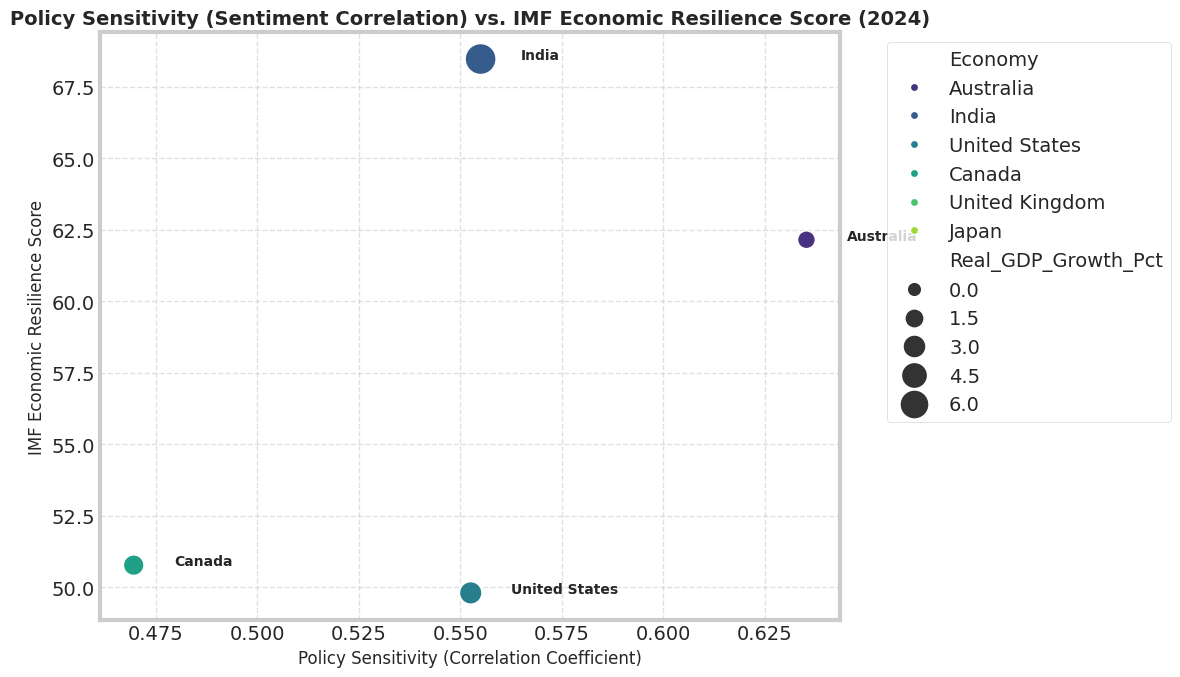

,Economy,Correlation,Economic_Resilience_Score,Real_GDP_Growth_Pct
0,Australia,0.635284,62.15,1.0
1,India,0.554988,68.47,7.1
2,United States,0.552550,49.80,2.8
3,Canada,0.469494,50.77,2.0
4,United Kingdom,NaN,50.79,1.1
5,Japan,NaN,42.10,-0.2


In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter IMF data for the latest vintage and target economies
# Mapping IMF names to our economy names where necessary
imf_latest = imf_df[imf_df['year'] == 2024].copy()

# 2. Merge Correlation data with IMF Resilience scores
sensitivity_resilience = pd.merge(
    corr_comparison_df,
    imf_latest[['country_name', 'Economic_Resilience_Score', 'Real_GDP_Growth_Pct']],
    left_on='Economy',
    right_on='country_name',
    how='inner'
)

# 3. Visualization
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Scatter plot with size based on GDP growth
scatter = sns.scatterplot(
    data=sensitivity_resilience,
    x='Correlation',
    y='Economic_Resilience_Score',
    size='Real_GDP_Growth_Pct',
    hue='Economy',
    sizes=(100, 500),
    palette='viridis',
    legend='brief'
)

# Add labels to points
for i in range(sensitivity_resilience.shape[0]):
    plt.text(
        sensitivity_resilience.Correlation[i]+0.01,
        sensitivity_resilience.Economic_Resilience_Score[i],
        sensitivity_resilience.Economy[i],
        fontsize=10,
        fontweight='bold'
    )

plt.title('Policy Sensitivity (Sentiment Correlation) vs. IMF Economic Resilience Score (2024)', fontsize=14, fontweight='bold')
plt.xlabel('Policy Sensitivity (Correlation Coefficient)', fontsize=12)
plt.ylabel('IMF Economic Resilience Score', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

display(sensitivity_resilience[['Economy', 'Correlation', 'Economic_Resilience_Score', 'Real_GDP_Growth_Pct']])

### 📉 IMF Resilience Forecast: 2024 vs 2026
Comparing the current structural resilience scores with the IMF's 2026 projections to identify shifting economic fundamentals.

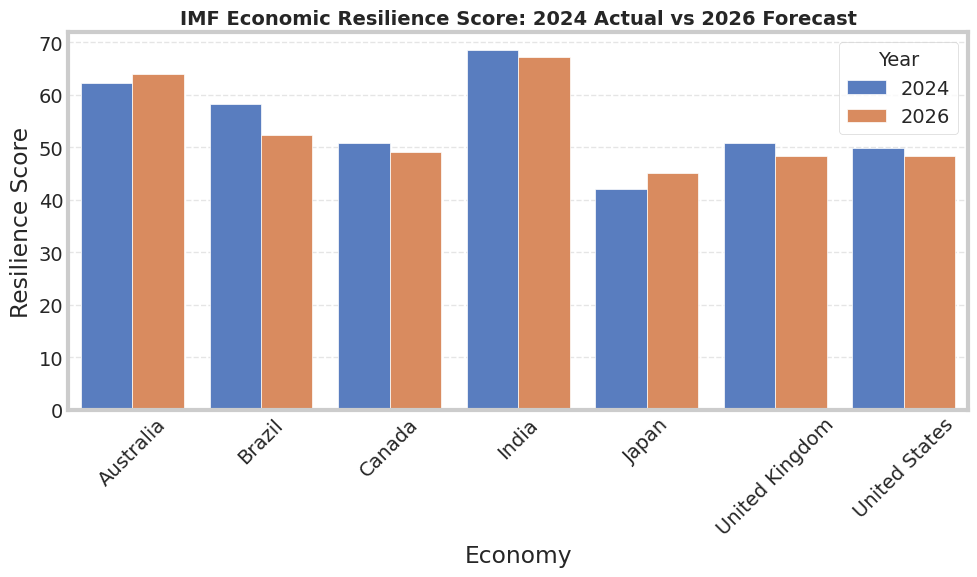

Economic Resilience Trend (2024 -> 2026):


year,2024,2026,Resilience_Delta
country_name,,,
Japan,42.10,45.00,2.90
Australia,62.15,64.02,1.87
India,68.47,67.12,-1.35
United States,49.80,48.27,-1.53
Canada,50.77,49.16,-1.61
United Kingdom,50.79,48.37,-2.42
Brazil,58.25,52.28,-5.97


In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define target economies based on our existing bank panel
target_economies = ['United States', 'United Kingdom', 'India', 'Japan', 'Canada', 'Australia', 'Brazil']

# 2. Filter IMF data for 2024 and 2026 for these economies
resilience_comp = imf_df[imf_df['country_name'].isin(target_economies) & imf_df['year'].isin([2024, 2026])].copy()

# 3. Pivot for easier delta calculation and plotting
res_pivot = resilience_comp.pivot(index='country_name', columns='year', values='Economic_Resilience_Score')
res_pivot['Resilience_Delta'] = res_pivot[2026] - res_pivot[2024]

# 4. Visualization: Slope Chart or Side-by-Side Bar
plt.figure(figsize=(10, 6))
sns.barplot(data=resilience_comp, x='country_name', y='Economic_Resilience_Score', hue='year', palette='muted')

plt.title('IMF Economic Resilience Score: 2024 Actual vs 2026 Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Economy')
plt.ylabel('Resilience Score')
plt.legend(title='Year')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("Economic Resilience Trend (2024 -> 2026):")
display(res_pivot.sort_values('Resilience_Delta', ascending=False))